In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import os
import random
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from keras.layers import Dense, GlobalAveragePooling2D
from keras.models import Model
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [31]:
# Constants
TRAIN_DIR = "./content/Training"
RESIZE_WIDTH = 224
RESIZE_HEIGHT = 224
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001

In [32]:
# Function to load data generators
def create_generators(base_dir, validation_split=0.2):
    data_gen = ImageDataGenerator(
        validation_split=validation_split, preprocessing_function=preprocess_input
    )
    
    train_generator = data_gen.flow_from_directory(
        base_dir,
        target_size=(RESIZE_WIDTH, RESIZE_HEIGHT),
        color_mode='rgb',
        batch_size=BATCH_SIZE,
        shuffle=True,
        subset='training'
    )

    val_generator = data_gen.flow_from_directory(
        base_dir,
        target_size=(RESIZE_WIDTH, RESIZE_HEIGHT),
        color_mode='rgb',
        batch_size=BATCH_SIZE,
        shuffle=False,
        subset='validation'
    )
    
    return train_generator, val_generator

In [33]:
# Function to structure the model
def structure_model(input_shape, num_classes):
    base_model = VGG16(weights="imagenet", include_top=False, input_shape=input_shape)
    for layer in base_model.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(1024, activation='relu')(x)
    x = Dense(512, activation='relu')(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model

In [34]:
# Function to plot training results
def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    plt.figure(figsize=(14, 7))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'r', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'b', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'r', label='Training Loss')
    plt.plot(epochs, val_loss, 'b', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.show()

In [35]:
# Load data generators for Stroke dataset
stroke_train_gen, stroke_val_gen = create_generators(os.path.join(TRAIN_DIR, "Stroke"))

# Create Stroke model
stroke_model = structure_model((RESIZE_WIDTH, RESIZE_HEIGHT, 3), num_classes=2)
stroke_model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=LEARNING_RATE), metrics=['accuracy'])

Found 1538 images belonging to 2 classes.
Found 384 images belonging to 2 classes.


In [36]:
# Train Stroke model
stroke_callbacks = [
    ModelCheckpoint("model/stroke_best_model.keras", save_best_only=True, monitor="val_loss"),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
]

stroke_history = stroke_model.fit(
    stroke_train_gen,
    validation_data=stroke_val_gen,
    epochs=EPOCHS,
    callbacks=stroke_callbacks
)

Epoch 1/10


C:\Users\vaibh\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


49/49 ━━━━━━━━━━━━━━━━━━━━ 133s 3s/step - accuracy: 0.6709 - loss: 1.8088 - val_accuracy: 0.7578 - val_loss: 0.4945 - learning_rate: 0.0010
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.8959 - loss: 0.2930 - val_accuracy: 0.8021 - val_loss: 0.4777 - learning_rate: 0.0010
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.9175 - loss: 0.2137 - val_accuracy: 0.7839 - val_loss: 0.5030 - learning_rate: 0.0010
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.9245 - loss: 0.1777 - val_accuracy: 0.8151 - val_loss: 0.4643 - learning_rate: 0.0010
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.9410 - loss: 0.1586 - val_accuracy: 0.7891 - val_loss: 0.5101 - learning_rate: 0.0010
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.9655 - loss: 0.0979 - val_accuracy: 0.8047 - val_loss: 0.7289 - learning_rate: 0.0010
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.9805 - loss: 0.0652 - val_accuracy: 0.80

In [37]:
# Evaluate Stroke model
stroke_predictions = stroke_model.predict(stroke_val_gen)
stroke_true_labels = stroke_val_gen.classes
stroke_predicted_labels = np.argmax(stroke_predictions, axis=1)

# Classification report and confusion matrix for Stroke
stroke_cr = classification_report(stroke_true_labels, stroke_predicted_labels, target_names=list(stroke_train_gen.class_indices.keys()))
print("Stroke Classification Report:\n", stroke_cr)

12/12 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step
Stroke Classification Report:
               precision    recall  f1-score   support

          no       0.83      0.80      0.81       192
         yes       0.80      0.83      0.82       192

    accuracy                           0.82       384
   macro avg       0.82      0.82      0.82       384
weighted avg       0.82      0.82      0.82       384



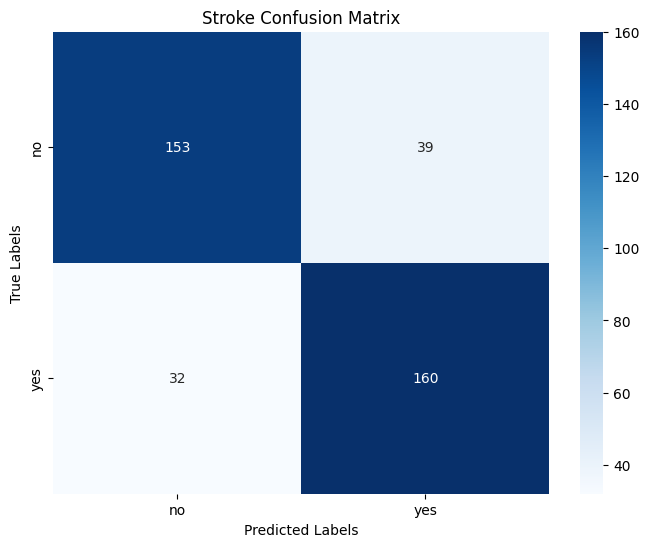

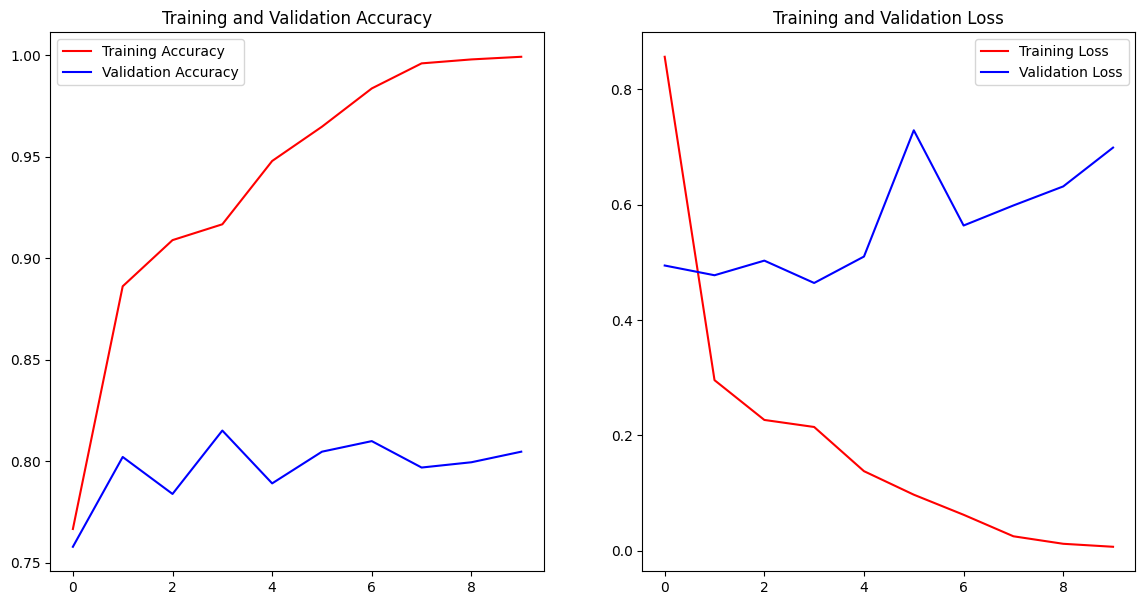

In [38]:
stroke_cm = confusion_matrix(stroke_true_labels, stroke_predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(stroke_cm, annot=True, fmt='d', cmap='Blues', xticklabels=stroke_train_gen.class_indices.keys(), yticklabels=stroke_train_gen.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Stroke Confusion Matrix')
plt.show()

# Plot Stroke training results
plot_training(stroke_history)

In [39]:
# Load data generators for Tumor dataset
tumor_train_gen, tumor_val_gen = create_generators(os.path.join(TRAIN_DIR, "Tumor"))

# Create Tumor model
tumor_model = structure_model((RESIZE_WIDTH, RESIZE_HEIGHT, 3), num_classes=2)
tumor_model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=LEARNING_RATE), metrics=['accuracy'])

# Train Tumor model
tumor_callbacks = [
    ModelCheckpoint("model/tumor_best_model.keras", save_best_only=True, monitor="val_loss"),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
]

Found 248 images belonging to 2 classes.
Found 62 images belonging to 2 classes.


In [40]:
tumor_history = tumor_model.fit(
    tumor_train_gen,
    validation_data=tumor_val_gen,
    epochs=EPOCHS,
    callbacks=tumor_callbacks
)

# Evaluate Tumor model
tumor_predictions = tumor_model.predict(tumor_val_gen)
tumor_true_labels = tumor_val_gen.classes
tumor_predicted_labels = np.argmax(tumor_predictions, axis=1)

Epoch 1/10


C:\Users\vaibh\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


8/8 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5076 - loss: 5.9039 - val_accuracy: 0.8226 - val_loss: 0.4487 - learning_rate: 0.0010
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.7553 - loss: 0.7828 - val_accuracy: 0.8387 - val_loss: 0.3763 - learning_rate: 0.0010
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.8742 - loss: 0.3324 - val_accuracy: 0.7742 - val_loss: 0.7884 - learning_rate: 0.0010
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9371 - loss: 0.1820 - val_accuracy: 0.8871 - val_loss: 0.3787 - learning_rate: 0.0010
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.9762 - loss: 0.0988 - val_accuracy: 0.8065 - val_loss: 0.6692 - learning_rate: 0.0010
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.9818 - loss: 0.0651 - val_accuracy: 0.8871 - val_loss: 0.4715 - learning_rate: 5.0000e-04
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9986 - loss: 0.0437 - val_accuracy: 0.8226 - val_loss: 0.

Tumor Classification Report:
               precision    recall  f1-score   support

          no       0.86      0.81      0.83        31
         yes       0.82      0.87      0.84        31

    accuracy                           0.84        62
   macro avg       0.84      0.84      0.84        62
weighted avg       0.84      0.84      0.84        62



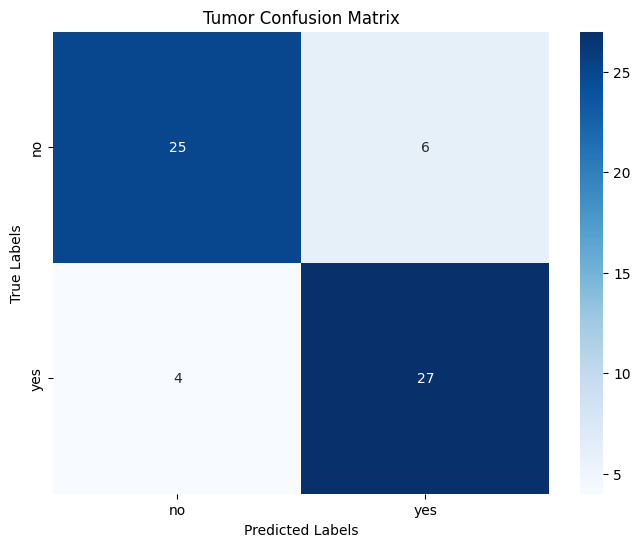

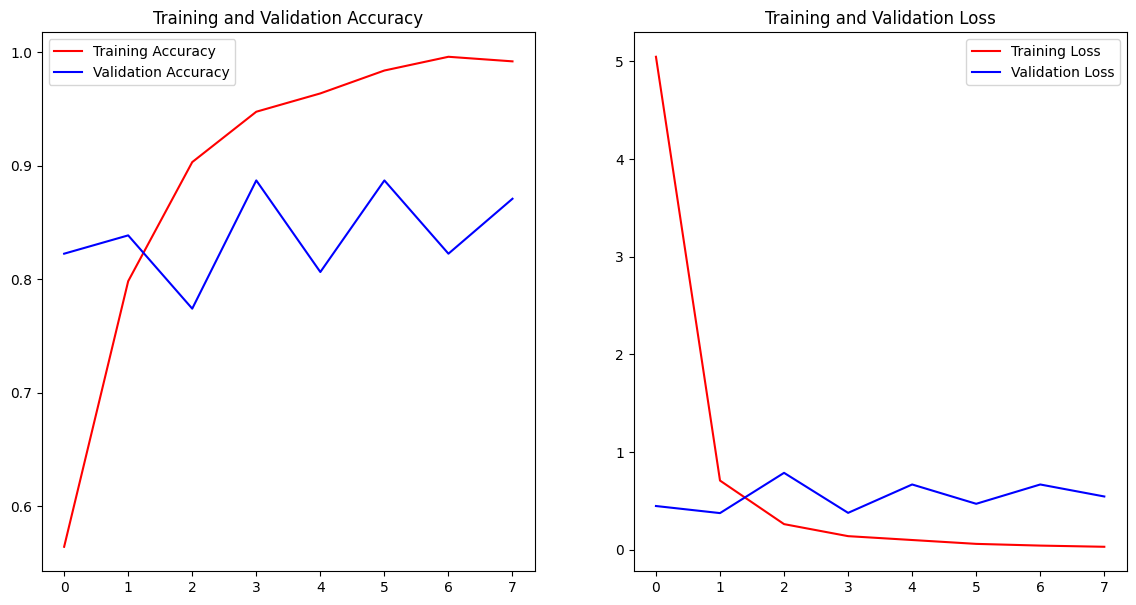

In [41]:
# Classification report and confusion matrix for Tumor
tumor_cr = classification_report(tumor_true_labels, tumor_predicted_labels, target_names=list(tumor_train_gen.class_indices.keys()))
print("Tumor Classification Report:\n", tumor_cr)

# Tumor Confusion Matrix
tumor_cm = confusion_matrix(tumor_true_labels, tumor_predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(tumor_cm, annot=True, fmt='d', cmap='Blues', xticklabels=tumor_train_gen.class_indices.keys(), yticklabels=tumor_train_gen.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Tumor Confusion Matrix')
plt.show()

# Plot Tumor training results
plot_training(tumor_history)